# 빈도수 기반 텍스트 분석 : 다음 영화 리뷰

1. 데이터 준비 : 로딩, 필요한 데이터 추출
2. 데이터 전처리 : 분석 대상 단어 집합
3. 데이터 분석 : 빈도수 추출
4. 시각화 : 수평 막대 그래프, 워드클라우드

### 1. 데이터 준비

In [2]:
import pandas as pd
datafile = './data/daum_movie_review.csv'
data_df = pd.read_csv(datafile)
data_df.head()

,review,rating,date,title
0,돈 들인건 티가 나지만 보는 내내 하품만,1,2018.10.29,인피니티 워
1,몰입할수밖에 없다. 어렵게 생각할 필요없다. 내가 전투에 참여한듯 손에 땀이남.,10,2018.10.26,인피니티 워
2,이전 작품에 비해 더 화려하고 스케일도 커졌지만.... 전국 맛집의 음식들을 한데 ...,8,2018.10.24,인피니티 워
3,이 정도면 볼만하다고 할 수 있음!,8,2018.10.22,인피니티 워
4,재미있다,10,2018.10.20,인피니티 워


In [3]:
data_df.info() # 결측치 확인 (기호만 있어서 기호를 없앴을 때 결측치가 발생할 수 있다.) => bow(bag of words)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14725 entries, 0 to 14724
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  14725 non-null  object
 1   rating  14725 non-null  int64 
 2   date    14725 non-null  object
 3   title   14725 non-null  object
dtypes: int64(1), object(3)
memory usage: 460.3+ KB


In [4]:
reviews = list(data_df.review)
len(reviews), reviews

(14725,
 ['돈 들인건 티가 나지만 보는 내내 하품만',
  '몰입할수밖에 없다. 어렵게 생각할 필요없다. 내가 전투에 참여한듯 손에 땀이남.',
  '이전 작품에 비해 더 화려하고 스케일도 커졌지만.... 전국 맛집의 음식들을 한데 모은 것까지는 좋았으나 이걸 모두 한 그릇에 섞어버린 듯한 느낌... 그래도 다음 작품을 기대하게 만든다...',
  '이 정도면 볼만하다고 할 수 있음!',
  '재미있다',
  '나는 재밌게 봄',
  '0.5점은 줄 수 없냐?',
  '헐..다 죽었어....나중에 앤트맨 보다가도 깜놀...',
  '충격 결말',
  '응집력',
  '개연성은 무시해라 액션을 즐겨라 스타로드가 이끌어준다 각각의 영웅들을 즐겨라 그리고 단적인 신념이 얼마나 부질없는지 보셔라',
  '내가졸라이상하네',
  '대박',
  '정말 지루할틈없이 넘잘만들었다 역시 대단하다',
  '역시 어벤져스!!',
  '마지막에 누구한테 연락한거지? 궁금',
  '다음 편이 궁굼해지네요^^',
  '안잼있는사람 있음???????????',
  '타노스 개갞기',
  '잘 만들었다! 지루할 틈이 없네...',
  '이제는 지겨워서 못보겠다',
  '롱턱 타노스의  장갑이 참 맘에 듬.  아이언 맨과 토르 닥터만 생고생하고..  가디언즈 오브 갤럭시 들 때문에  손해가 크다고 봄  들짐승 하고 칡뿌리 같은 캐릭이  재미를 더해줄줄 알았으나  아쉬움 . 분노의 상징 헐크가 겁을 먹다니..로키의 초반 출연뿐이 서운하지만  본 영화에 이어질 내용에 적합하지 않은지 서두에  죽는부분으로 마무리 됨은 심섬한 충격임 .  다음편에 헬라가 다시 나올까?',
  '내 인생 명작',
  '와~~~~~진짜 개쪄는 인피니티워!!몇번을 봐도 개지린다.너무잼있다.어벤져스4도 너무 기대된다.빨리 2019년이왔으면 좋겠다.',
  '종합선물세트지만 가장 중요한 마무리가 없는 예고편!!!',
  '기대만큼 실망도크네요 임펙트도없고  내용도 그닥 너무억지',
  '이 영화를 보고나서 예전 

### 2. 데이터 전처리

In [5]:
from konlpy.tag import Okt
t = Okt()

# 명사만 추출
nouns = [n for s in reviews for n in t.nouns(s)]
# 토큰 수
print(f"토큰 수 : {len(nouns)}")

# 토큰 일부 확인
nouns[:10]

토큰 수 : 126063


['돈', '티', '나', '내내', '하품', '몰입', '생각', '내', '전투', '참여']

In [7]:
# 명사(일반 명사, 고유 명사), 동사, 형용사 단어 추출
my_tags = ['Noun', 'Adjective', 'Verb']
# 불용어 삭제 : 의미없는데 고빈도로 나오는 단어 추가
my_stopwords = ['제', '하는', '때', '나', '내', '내내', '티']
tokens = []
for s in reviews:
    # 문장 단위로 한 번만 품사 태깅을 수행
    pos_result = t.pos(s, stem=True) 
    
    # 조건에 맞는 단어만 리스트에 추가
    for word, tag in pos_result:
        if tag in my_tags and word not in my_stopwords and len(word) > 1:
            tokens.append(word)
# 토큰 수
print(f"토큰 수 : {len(tokens):,}개")
# 토큰 일부 확인
tokens[:10]

토큰 수 : 167,323개


['들이다', '보다', '하품', '몰입', '하다', '없다', '어렵다', '생각', '하다', '필요없다']

## 3. 빈도수 계산

In [8]:
# Counter 객체 생성
from collections import Counter
const_counter = Counter(tokens)

# 단어 수
print(len(const_counter))

# Counter 객체 내 (단어, 빈도수) 확인
print(list(const_counter.items())[:50])

11298
[('들이다', 77), ('보다', 5902), ('하품', 33), ('몰입', 210), ('하다', 6893), ('없다', 1683), ('어렵다', 58), ('생각', 1027), ('필요없다', 57), ('전투', 11), ('참여', 8), ('이남', 3), ('이전', 16), ('작품', 241), ('비다', 73), ('화려하다', 133), ('스케일', 60), ('커지다', 11), ('전국', 6), ('맛집', 1), ('음식', 10), ('모으다', 36), ('좋다', 1791), ('모두', 245), ('그릇', 2), ('섞다', 17), ('버리다', 194), ('느낌', 398), ('다음', 207), ('기대하다', 223), ('만들다', 774), ('정도', 531), ('있다', 2304), ('재미있다', 768), ('재밌다', 1148), ('헐다', 24), ('죽다', 273), ('나중', 56), ('앤트맨', 13), ('깜놀', 16), ('충격', 59), ('결말', 183), ('응집', 1), ('개연', 83), ('성은', 16), ('무시', 19), ('액션', 268), ('즐기다', 54), ('스타로드', 14), ('이끌다', 31)]


In [9]:
# 빈도수 상위 단어의 (단어, 빈도수) 튜플 리스트 추출
const_counter.most_common(50)

[('하다', 6893),
 ('영화', 6691),
 ('보다', 5902),
 ('있다', 2304),
 ('좋다', 1791),
 ('없다', 1683),
 ('이다', 1654),
 ('되다', 1478),
 ('연기', 1293),
 ('않다', 1290),
 ('같다', 1252),
 ('감동', 1223),
 ('재밌다', 1148),
 ('아니다', 1080),
 ('생각', 1027),
 ('나오다', 967),
 ('정말', 948),
 ('자다', 901),
 ('가다', 866),
 ('배우', 847),
 ('사람', 819),
 ('스토리', 815),
 ('진짜', 781),
 ('만들다', 774),
 ('재미있다', 768),
 ('눈물', 737),
 ('보고', 702),
 ('최고', 682),
 ('무섭다', 666),
 ('재미', 641),
 ('마지막', 612),
 ('시간', 596),
 ('많다', 596),
 ('들다', 572),
 ('마동석', 556),
 ('모르다', 553),
 ('지루하다', 538),
 ('싶다', 536),
 ('그냥', 533),
 ('정도', 531),
 ('광주', 530),
 ('윤계상', 517),
 ('기대', 516),
 ('그렇다', 501),
 ('내용', 494),
 ('오다', 483),
 ('아깝다', 482),
 ('넘다', 469),
 ('주다', 460),
 ('장면', 438)]

## 4. 단어 빈도 그래프 시각화
1. 데이터 준비
2. 그래프 정보 추가
3. 막대 그래프 생성
4. 그래프 출력 (화면, 파일)

In [10]:
# 데이터 준비 : 빈도수 상위 20개의 단어만 추출
# x 데이터 : word, y 데이터 : count
x = [word for word, _ in const_counter.most_common(20)]
y = [count for _, count in const_counter.most_common(20)]
print(x[:10])
print(y[:10])

['하다', '영화', '보다', '있다', '좋다', '없다', '이다', '되다', '연기', '않다']
[6893, 6691, 5902, 2304, 1791, 1683, 1654, 1478, 1293, 1290]


In [11]:
# matplotlib 한글 폰트 설정
from matplotlib import font_manager, rc
font_path = "c:/Windows/Fonts/malgun.ttf"
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)

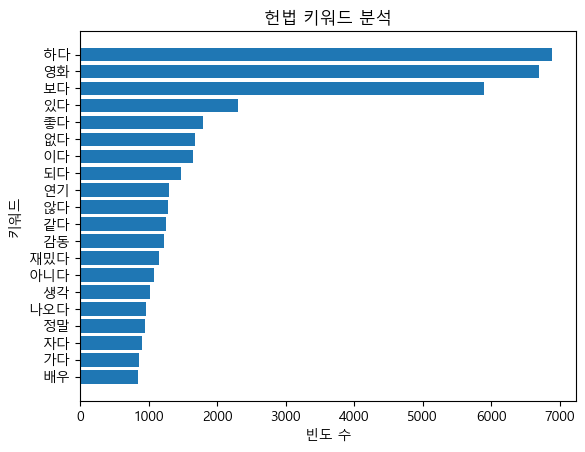

In [12]:
import matplotlib.pyplot as plt

# 수평 막대그래프
plt.barh(x[::-1],y[::-1])

# 그래프 정보 추가 
plt.title('헌법 키워드 분석')
plt.xlabel('빈도 수')
plt.ylabel('키워드')
# 화면에 출력
plt.show()

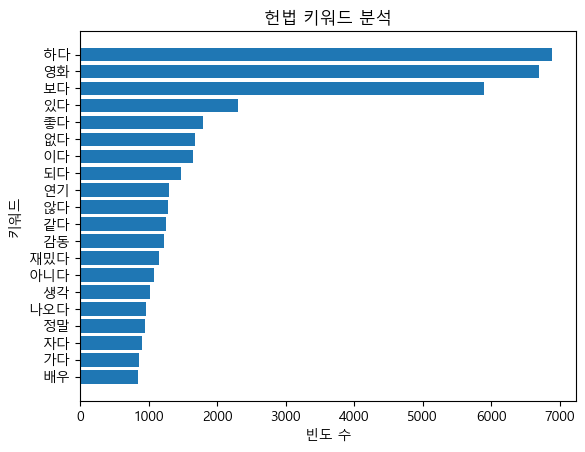

In [18]:
plt.barh(x[::-1],y[::-1])
plt.title('헌법 키워드 분석')
plt.xlabel('빈도 수')
plt.ylabel('키워드')
# 그래프 저장 : 그래프 생성 후 바로 savefig 사용
outputfile = datafile.replace('.csv', '_bargraph.png')
plt.savefig(outputfile) # show 필요없이 저장하고 출력까지 해준다, show를 한 후에 하면 정보가 사라져 있다

### 03-5. 워드 클라우드 시각화


* conda 환경에서 wordcloud 설치 (conda install wordcloud)

In [15]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 한글 폰트 path 지정
font_path = "c:/Windows/fonts/malgun.ttf"

# WordCloud 객체 생성
const_wc = WordCloud(font_path=font_path, 
                     background_color='ivory'
                     )

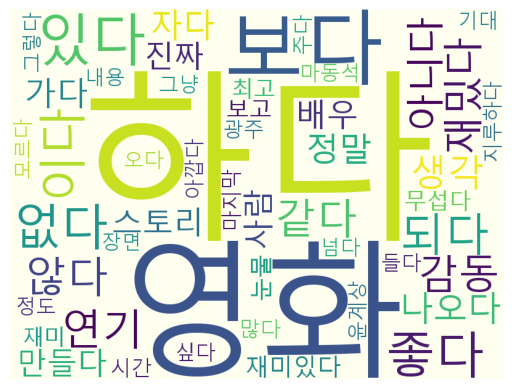

In [17]:
# 빈도 데이터로 워드클라우드 시각화
const_wc = WordCloud(font_path=font_path, 
                     width=800,
                     height=600,
                     max_words=50,
                     background_color='ivory'
                     )
const_wc = const_wc.generate_from_frequencies(const_counter)
plt.imshow(const_wc)
plt.axis('off')
plt.show()